# 量子游走搜索算法

量子游走是经典马尔可夫链的量子等价物，它已成为许多量子算法的关键组成部分。本节我们将实现一个量子游走搜索算法，用于在图中寻找标记元素。与经典算法相比，该算法具有二次加速的优势。

## 经典马尔可夫链

马尔可夫链是一种随机过程，通常用于对现实生活中的过程进行建模。它由状态和相关的转移概率组成，转移概率描述了在每个时间步长内在状态之间移动的概率。在我们这里使用的离散时间马尔可夫链中，时间步长是离散的。马尔可夫链满足马尔可夫性质，这意味着过程的下一步只取决于当前步骤，而不取决于之前的任何步骤。马尔可夫链有一个相关的转移矩阵P，描述了在每个状态之间移动的概率。下面我们展示了一个马尔可夫链及其相关转移矩阵P的示例。

$$
P = \begin{pmatrix}
0.1 & 0.3 & 0.3 \\
0.1 & 0.1 & 0.2 \\
0.3 & 0.6 & 0.5
\end{pmatrix}
$$

<div style="margin-right: 15px; border-radius: 10px; background-color: rgb(255， 255， 255); text-align: center;">
    <img src="./images/3_6_0001.png" width="30%"/>
    <p style="padding: 10px; font-size: small; text-align: center; line-height: 0%;">
        <b>
    </p>
</div>

给定转移矩阵P，我们可以通过 $P^t$ 获得t个时间步长后的概率分布。

## 量子游走

量子游走是经典马尔可夫链的量子等价物。由于叠加态的存在，量子游走将同时走过所有可能的路径，直到我们对线路进行测量。由于量子干涉，一些状态将被抵消。这使得量子游走算法比经典算法更快，因为我们可以设计它们，使错误答案快速抵消。量子游走有两种常见的模型：硬币式量子游走和Szegedy量子游走,它们在某些情况下是等价的。硬币式量子游走发生在图的顶点上，而Szegedy量子游走发生在边上。在展示如何实现量子游走之前，我们将介绍这两种模型。

### 硬币式量子游走

硬币式量子游走的一个简单示例是在无限整数线上的游走。在这种情况下，我们用一个整数 $\{\ket{j} : j \in \mathbb{Z} \}$ 来表示游走者的位置，因为游走者可以走遍 $\mathbb{Z}$ 中的所有整数。我们可以用一枚硬币决定游走者应该如何移动。在整数线上，游走者可以向左或向右移动。因此，硬币的计算基础是 $\{\ket{0}, \ket{1}\}$ ，如果硬币是 $\ket{0}$ ，我们将游走者向一个方向移动，如果硬币是 $\ket{1}$ ，则向另一个方向移动。

硬币式量子游走是在图节点上的游走，我们将节点称为状态。游走者可以在由边连接的状态之间移动。在硬币模型中，我们有两个量子态和两个算符。第一个状态是位置状态，表示游走者的位置，游走者可以位于整数线上的任何整数位置。另一个状态是硬币状态。硬币状态决定游走者在下一步中应该如何移动。我们可以用Hilbert空间中的向量来表示硬币状态和位置状态。如果我们可以用 $\mathcal{H}_C$ 中的向量表示硬币状态，用 $\mathcal{H}_P$ 中的向量表示位置状态，那么我们可以将整个游走者的量子空间表示为 $\mathcal{H} = \mathcal{H}_C \otimes \mathcal{H}_P$ 。

如前所述，该模型还有两个算符：硬币算符C和移位算符S。硬币算符在每个时间步长内作用于 $\mathcal{H}_C$ ，使游走者进入叠加态，从而同时走过所有可能的路径。对于整数线上的游走，这意味着它在每个时间步长内既向左移动又向右移动。有不同的硬币算符，但最常见的是Hadamard硬币和Grover硬币。Hadamard硬币是一个Hadamard门，它使游走者处于相等的叠加态：

$$
\begin{equation}
H = \frac{1}{\sqrt{2}}
\begin{bmatrix}
1 & 1 \\
1 & -1
\end{bmatrix}
\end{equation}
$$

Grover硬币是来自Grover算法的Grover扩散算符。我们将其定义为

$$
\begin{equation}
G =
\begin{bmatrix}
\frac{2}{n} -1 & \frac{2}{n} & \ldots & \frac{2}{n}\\
\frac{2}{n} & \frac{2}{n} - 1 & \ldots & \frac{2}{n} \\
\vdots & \vdots & \ddots & \vdots \\
\frac{2}{n} & \frac{2}{n} & \ldots & \frac{2}{n} -1
\end{bmatrix}
\end{equation}
$$

与Hadamard硬币一样，Grover硬币也使游走者进入叠加态。但是，它的行为有点不同。如果我们将Grover硬币应用于位置 $\ket{000}$ 的游走者，硬币没有像Hadamard硬币那样使游走者处于相等的叠加态。相反， $\ket{000}$ 的概率远大于其他状态。

该模型中的另一个算符，移位算符作用于 $\mathcal{H}_P$ ，将游走者移动到下一个位置。对于整数线上的游走，如果硬币为 $\ket{0}$ ，移位算符将游走者向左移动，如果硬币为 $\ket{1}$ ，则向右移动：

$$
\begin{equation}
S \ket{0}\ket{j} = \ket{0}\ket{j+1}
\end{equation}
$$

$$
\begin{equation}
S \ket{1}\ket{j} = \ket{1}\ket{j-1}
\end{equation}
$$

定义了上述移位算符后，我们可以将硬币式量子游走的一步表示为幺正算符 $U$，其中

$$
\begin{equation}
U = SC,
\end{equation}
$$

其中C是硬币算符。对于整数线上的量子游走，我们使用Hadamard硬币，但C可以是Hadamard硬币、Grover硬币或任何其他硬币算符。

我们还可以展望几步。我们可以将t个时间步长后的量子态 $\ket{\psi}$ 表示为

$$
\begin{equation}
\ket{\psi (t)} = U^t \ket{\psi(0)},
\end{equation}
$$

其中 $\ket{\psi(0)}$ 是初始状态， $U$ 是游走一步的算符[1]。

硬币式量子游走最适合于正则图，即所有节点都具有相同数量邻居的图[2]。另一种更适合非正则图的量子游走模型是我们接下来要看的Szegedy模型。

### Szedgedy量子游走
与基于硬币的量子游走在图的节点上进行不同，Szegedy量子游走是基于图的边的，是一种离散时间量子游走模型，但不依赖于硬币操作。为了构建这个模型，我们从经典游走的转移概率矩阵P开始。我们用转移矩阵P来表示经典的离散时间随机游走。对于任何具有 $N \times N$ 转移矩阵P的N个节点的图，我们可以将相应的离散时间量子游走定义为希尔伯特空间 $\mathcal{H}^N \otimes \mathcal{H}^N$ 上的幺正算符。设 $P_{jk}$ 表示从状态 $j$ 转移到 $k$ 的概率。在定义游走之前，我们先定义归一化状态

$$
\begin{equation}
    \ket{\psi_j} := \sum_{k=1}^N \sqrt{P_{kj}} \ket{j,k}, \; j=1,...,N
\end{equation}
$$

以及到 ${\ket{\psi_j}}:j=1,...,N$ 上的投影

$$
\begin{equation}
    \Pi := \sum_{j=1}^N \ket{\psi_j} \bra{\psi_j}
\end{equation}
$$

我们还引入了移位算符S：

$$
\begin{equation}
    S := \sum_{j,k=1}^N \ket{j,k} \bra{k,j}
\end{equation}
$$

根据上面定义的 $S$ 和 $\Pi$ ，我们可以给出离散时间量子游走的一步演化：

$$
\begin{equation}
    U := S(2 \Pi - 1),
\end{equation}
$$

其中 $(2 \Pi - 1)$ 是反射算符。我们还将 $t$ 步游走定义为 $U^t$ [2]。


## 示例：在超立方体上实现量子游走

超立方体是3维立方体在 $n$ 维空间的推广。所有节点的度为 $n$ ，超立方体总共有 $N=2^n$ 个节点。我们可以用二进制数的 $n$ 元组来表示超立方体图中的节点。一个节点的邻居节点的二进制表示只会有一位不同。例如，在4维超立方体中， $0000$ 的邻居是 $0001$ 、 $0010$ 、 $0100$ 和 $1000$ 。因此，一个节点与所有到它的汉明距离为1的节点相连。边也是有标号的。两个相邻节点在第 $a$ 位上不同，它们之间的边就标号为 $a$ 。

表示超立方体上基于硬币的量子游走的希尔伯特空间是 $\mathcal{H} = \mathcal{H}^n \otimes \mathcal{H}^{2^n}$ ，其中 $\mathcal{H}^n$ 表示硬币空间， $\mathcal{H}^{2^n}$ 表示行走者的位置。计算基为

$$
\begin{equation}
    \big\{ \ket{a,\vec{v}}, 0 \leq a \leq n-1, \vec{v} \in  \{(00...00), (00...01), ....., (11...11 )\} \big\}.
\end{equation}
$$

硬币计算基 $a$ 的值与边 $a$ 相关联，它决定了行走者应该移动到哪里。如果 $a=0$ ，行走者将移动到第一个二进制值与当前节点不同的节点。如果 $a=1$ ，行走者将移动到第二个值与当前值不同的节点，以此类推。设 $\vec{e}_a$ 为一个 $n$ 元组，除了索引为 $a$ 的值之外，其他所有二进制值都为 $0$ 。则移位算符 $S$ 将行走者从状态 $\ket{a} \ket{\vec{v}}$ 移动到 $\ket{\vec{v} \oplus \vec{e}_a}$ ：

$$
\begin{equation}
    S \ket{a} \ket{\vec{v}} = \ket{a} \ket{\vec{v} \oplus \vec{e}_a}.
\end{equation}
$$

我们在这个游走中使用Grover硬币 $G$ 。因此，演化算符为

$$
\begin{equation}
    U = SG.
\end{equation}
$$

下面我们将展示如何在4维超立方体上实现量子游走。我们需要实现硬币算符和移位算符。

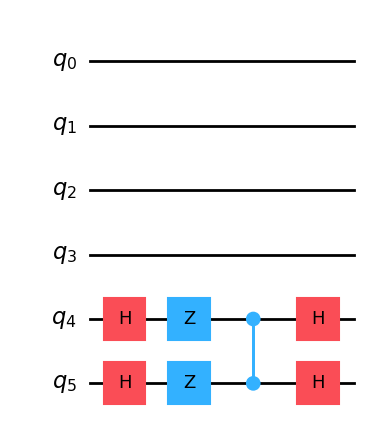

In [1]:
from typing import Any

import deepquantum as dq
import matplotlib.pyplot as plt
import torch

cir = dq.QubitCircuit(6)

cir.h(4)
cir.h(5)
cir.z(4)
cir.z(5)
cir.cz(4, 5)
cir.h(4)
cir.h(5)

cir.draw()

量子线路将有6个量子比特，4个表示位置，2个表示硬币。如前所述，硬币是Grover硬币，它是Grover算法中的扩散器。我们首先来实现它。

现在，让我们来实现移位算符。我们知道行走者只能移动到相邻节点，所有相邻节点只有一个比特不同。我们希望根据硬币来移动行走者，通过对节点量子比特之一应用非门来移动行走者。如果硬币处于状态 $\ket{11}$ ，我们将行走者移动到第一个节点量子比特不同的状态。如果硬币是 $\ket{10}$ 或 $\ket{01}$ ，行走者分别移动到第二个和第三个量子比特不同的状态。最后，如果Grover硬币是 $\ket{00}$ ，我们翻转第四个量子比特。我们在Grover硬币之后用CCNOT门和非门来实现这一点。它们一起构成了4维超立方体上量子游走的一步。

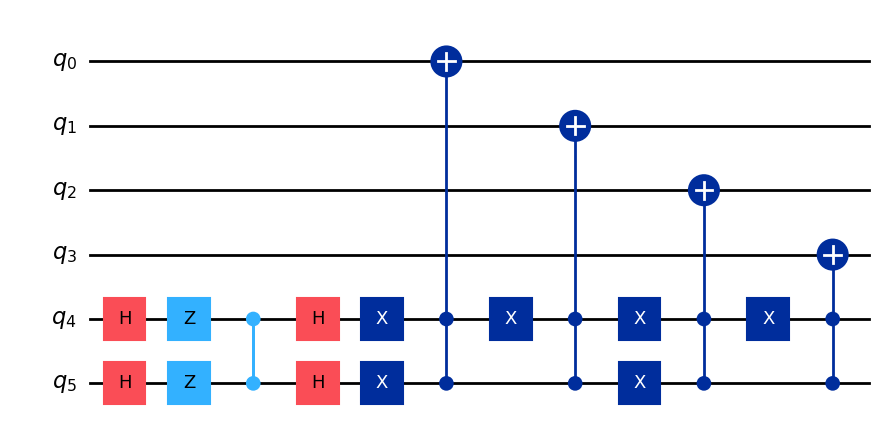

In [2]:
cir = dq.QubitCircuit(6)

cir.h(4)
cir.h(5)
cir.z(4)
cir.z(5)
cir.cz(4, 5)
cir.h(4)
cir.h(5)

for i in range(0, 4):
    cir.x(4)
    if i % 2 == 0:
        cir.x(5)
    cir.ccx(4, 5, i)


cir.draw()

## 量子游走搜索算法

现在我们将实现一个量子游走搜索算法来寻找图中的标记顶点。我们标记某些顶点集合 $|M|$ ，从图中任意一个节点开始，根据游走规则移动直到找到标记节点。量子游走搜索算法中的基态有两个寄存器，一个对应当前节点，另一个对应前一个节点。也就是说，基态对应于图中的边。我们用幺正算符 $W(P)$ 表示基于经典马尔可夫链转移矩阵 $P$ 的量子游走在 $\mathcal{H}$ 上的演化。我们还定义 $\ket{p_x} = \sum_y \sqrt{P_{xy}}\ket{y}$ 为节点 $x$ 的邻居上的均匀叠加态。设 $\ket{x}\ket{y}$ 为一个基态。如果 $x$ 是标记节点，我们称基态 $\ket{x}\ket{y}$ 为"好"的基态，否则称其为"坏"的基态。现在我们引入"好"态和"坏"态：

$$
\begin{equation}
    \ket{G} = \frac{1}{\sqrt{|M|}} \sum_{x \in M} \ket{x} \ket{p_x}, \;
    \ket{B} = \frac{1}{\sqrt{N-|M|}} \sum_{x \notin M} \ket{x} \ket{p_x},
\end{equation}
$$

它们分别是好的基态和坏的基态的叠加态。接下来，定义 $\epsilon = |M|/N$ 和 $\theta = \arcsin(\sqrt{\epsilon})$。

简而言之，该算法由三个步骤组成：

1. 设置初始态 $\ket{U} = \frac{1}{\sqrt{N}} \sum_{x} \ket{x} \ket{p_x} = \sin{\theta} \ket{G} + \cos{\theta} \ket{B}$ ，即所有边上的均匀叠加态
2. 重复 $O(1/\sqrt{\epsilon})$ 次：

    (a) 关于 $\ket{B}$ 反射

    (b) 关于 $\ket{U}$ 反射

3. 在计算基上做测量

我们可以用Hadamard门轻松实现第1步，用相位算符实现关于 $\ket{B}$ 的反射，它在 $x$ 在第一个寄存器中时改变 $x$ 的相位，否则线路保持不变。

步骤2(b)等价于找到一个幺正算符 $R(P)$ ，执行以下映射：

$$
\begin{align}
    \ket{U} &\mapsto \ket{U}, \: \text{且} \\
    \ket{\psi} &\mapsto -\ket{\psi}, \: \forall \ket{\psi} \text{在$W(P)$的本征向量张成的空间中且与 $\ket{U}$ 正交}
\end{align}
$$

为了找到这个算符，我们对 $W(P)$ 应用相位估计。前面我们将 $W(P)$ 定义为随机游走的演化算符， $W(P)$ 的本征值模为 $1$ 。因此，我们可以将 $W(P)$ 的本征值写成 $e^{\pm 2i\theta_j}$ 的形式。幺正算符 $W(P)$ 有一个本征向量，相应的本征值为 $1$ ，即 $\ket{U}$ 。这由 $\theta_1=0$ 给出。 $R(P)$ 将通过增加一个含有辅助量子比特的寄存器并以 $O(1/\sqrt{\delta})$ 的精度执行相位估计来找到这个向量 $\ket{U}$ ，其中 $\delta$ 是 $P$ 的谱间隙。为此，我们需要应用 $W(P)$ $O(1/\sqrt{\delta})$ 次。设 $\ket{w}$ 是 $W(P)$ 的本征向量，相应的本征值为 $e^{\pm 2i\theta_j}$ 。假设 $\tilde{\theta_j}$ 是由相位估计给出的对 $\theta_j$ 的最佳近似。在步骤2(b)中对 $\ket{w}$ 执行映射的算符 $R(P)$ 由下式给出[3]

$$
\begin{equation}
    \ket{w} \ket{0} \mapsto \ket{w} \ket{\tilde{\theta_j}} \mapsto (-1)^{|\tilde{\theta_j} \neq 0|} \ket{w} \ket{\tilde{\theta_j}} \mapsto (-1)^{|\tilde{\theta_j} \neq 0|} \ket{w} \ket{0}
\end{equation}
$$

## 示例：在4维超立方体上的量子游走搜索

量子游走搜索算法可以在 $O(1/\sqrt{\epsilon})$ 步内找到一组被标记的节点，$\epsilon = |M|/N$ ，其中 $M$ 是被标记节点的数量， $N$ 是节点总数。该算法最初与 Szegedy 量子游走一起使用,我们使用两个节点寄存器来表示量子态。然而，带有 Grover coin 的 coined 游走等价于 Szegedy 量子游走，而且由于 coined 游走的实现通常更简单，因此我们选择用 coined 游走来实现该算法。我们将使用第 3 节中实现的 4 维超立方体。

我们将按如下方式实现该算法。我们通过对节点量子位和硬币量子位应用 Hadamard 门来实现步骤 1，即在所有边上的均匀叠加。对于步骤 2(a)，我们实现一个相位 oracle。步骤 2(b)通过对超立方体上的量子游走的一步执行相位估计来实现，然后标记所有 $\theta \neq 0$ 的量子态。我们通过旋转辅助量子位来实现这一点。在该步骤的最后部分，我们反转相位估计。 theta 量子位的数量取决于 $\theta$ 的精度。

下面，我们在 4 维超立方体上实现量子游走搜索算法。

对于该算法，我们需要使用前面实现的单步门的逆。我们通过使用内置的线路函数 inverse() 来实现这一点。

In [ ]:
class OneStepCircuit(dq.Ansatz):
    def __init__(
        self,
        nqubit: int,
        minmax: list[int] | None = None,
        controls: int | list[int] | None = None,
        reverse: bool = False,
        init_state: Any = 'zeros',
        den_mat: bool = False,
        mps: bool = False,
        chi: int | None = None,
        show_barrier: bool = False,
    ) -> None:
        super().__init__(
            nqubit=nqubit,
            wires=None,
            minmax=minmax,
            ancilla=None,
            controls=controls,
            init_state=init_state,
            name='one_step_circuit',
            den_mat=den_mat,
            mps=mps,
            chi=chi,
        )

        self.one_step(controls)

    def one_step(self, controls):
        self.h(self.wires[4], controls=controls)
        self.h(self.wires[5], controls=controls)
        self.z(self.wires[4], controls=controls)
        self.z(self.wires[5], controls=controls)

        if controls is not None:
            self.z(wires=[self.wires[5]], controls=[controls, self.wires[4]])
        else:
            self.cz(self.wires[4], self.wires[5])

        self.h(self.wires[4], controls=controls)
        self.h(self.wires[5], controls=controls)

        for i in self.wires[0:4]:
            self.x(self.wires[4], controls=controls)
            if i % 2 == 0:
                self.x(self.wires[5], controls=controls)

            if controls is not None:
                self.x(wires=i, controls=[controls, self.wires[4], self.wires[5]])
            else:
                self.ccx(self.wires[4], self.wires[5], i)

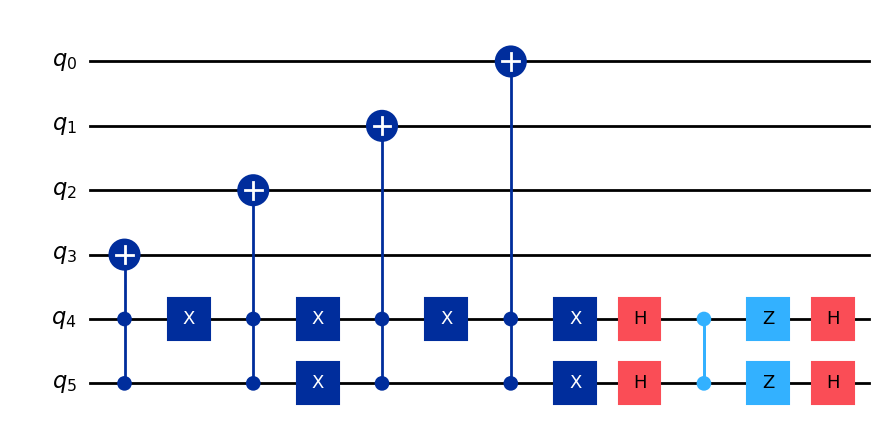

In [ ]:
cir = OneStepCircuit(nqubit=6, minmax=[0, 5])
cir.inverse().draw()

逆转的单步门将用于在稍后反转相位估计。我们需要从第 3 节中实现的单步门及其逆门制作受控门。我们稍后将根据控制量子位的值使用它们。

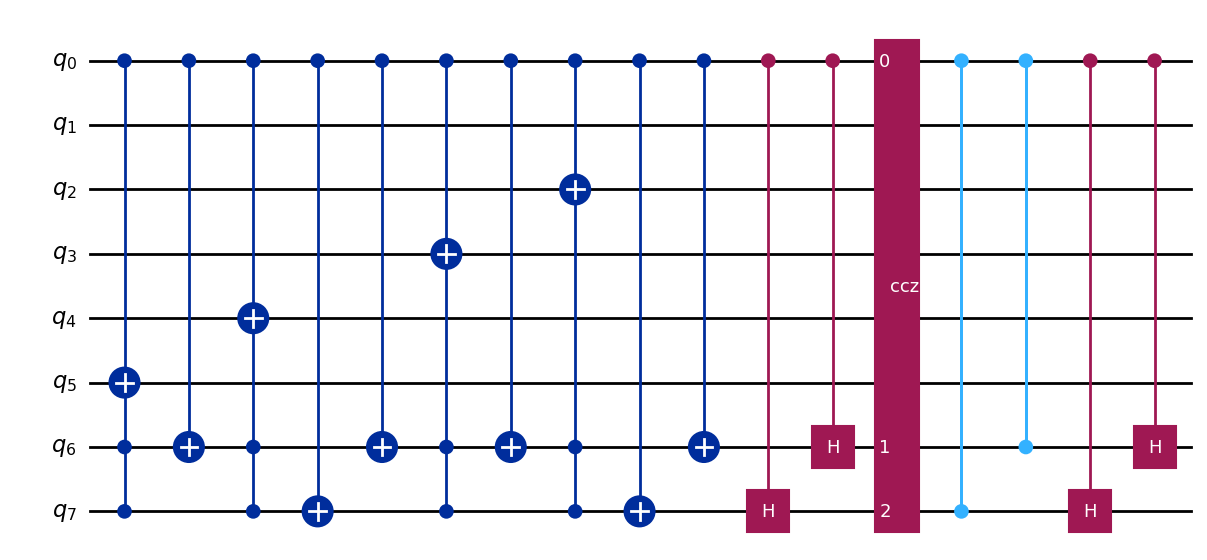

In [ ]:
cir = OneStepCircuit(nqubit=8, minmax=[2, 7], controls=0)
cir.inverse().draw()

受控单步门和受控逆单步门都将在相位估计中使用。我们将在相位估计中使用量子傅里叶变换。

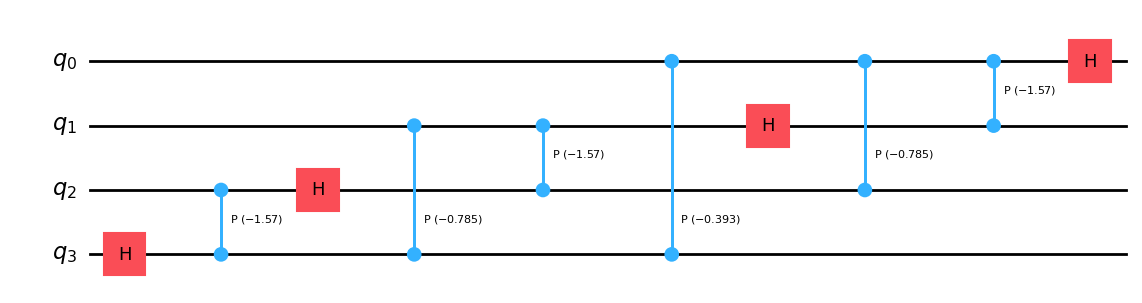

In [6]:
class QuantumFourierTransform(dq.Ansatz):
    def __init__(
        self,
        nqubit: int,
        minmax: list[int] | None = None,
        reverse: bool = False,
        init_state: Any = 'zeros',
        den_mat: bool = False,
        mps: bool = False,
        chi: int | None = None,
        show_barrier: bool = False,
    ) -> None:
        super().__init__(
            nqubit=nqubit,
            wires=None,
            minmax=minmax,
            ancilla=None,
            controls=None,
            init_state=init_state,
            name='QuantumFourierTransform',
            den_mat=den_mat,
            mps=mps,
            chi=chi,
        )
        self.reverse = reverse
        for i in self.wires:
            self.qft_block(i)
            if show_barrier:
                self.barrier(self.wires)
        if not reverse:
            for i in range(len(self.wires) // 2):
                self.swap([self.wires[i], self.wires[-1 - i]])

    def qft_block(self, n):
        self.h(n)
        k = 2
        for i in range(n, self.minmax[1]):
            self.cp(i + 1, n, torch.pi / 2 ** (k - 1))
            k += 1


QuantumFourierTransform(nqubit=4, minmax=[0, 3], reverse=True).inverse().draw()

在实现相位估计之前，我们实现一个相位 oracle，用于标记状态 1011 和 1111。然后，我们将其制作成量子线路。这是算法的步骤 2(a)。

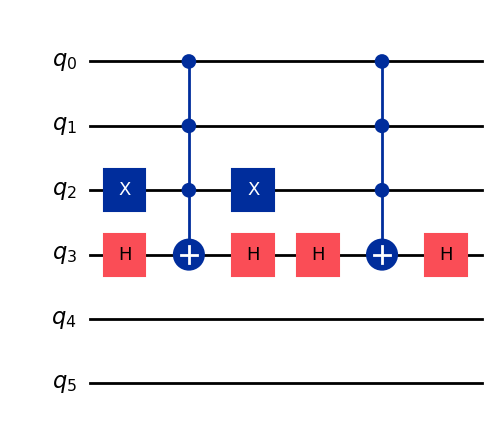

In [ ]:
class PhaseCircuit(dq.Ansatz):
    def __init__(
        self,
        nqubit: int,
        minmax: list[int] | None = None,
        controls: int | list[int] | None = None,
        reverse: bool = False,
        init_state: Any = 'zeros',
        den_mat: bool = False,
        mps: bool = False,
        chi: int | None = None,
        show_barrier: bool = False,
    ) -> None:
        super().__init__(
            nqubit=nqubit,
            wires=None,
            minmax=minmax,
            ancilla=None,
            controls=controls,
            init_state=init_state,
            name='phase_circuit',
            den_mat=den_mat,
            mps=mps,
            chi=chi,
        )

        # Mark 1011
        self.x(self.wires[2])
        self.h(self.wires[3])
        self.x(self.wires[3], controls=[self.wires[0], self.wires[1], self.wires[2]])
        self.h(self.wires[3])
        self.x(self.wires[2])
        # Mark 1111
        self.h(self.wires[3])
        self.x(self.wires[3], controls=[self.wires[0], self.wires[1], self.wires[2]])
        self.h(self.wires[3])


cir = PhaseCircuit(nqubit=6, minmax=[0, 5])
cir.draw()

现在，我们将实现一个门，如果其他量子位非零，则旋转辅助量子位。我们将在相位估计中使用此门，如果 $\theta \neq 0$，它将旋转辅助量子位。

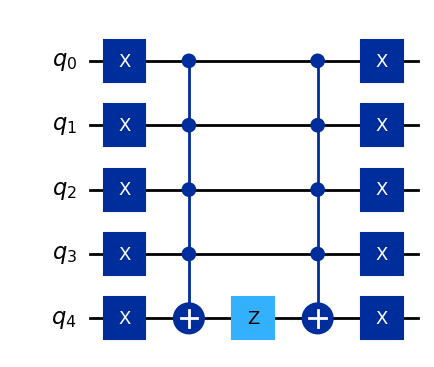

In [ ]:
class MarkAuxiliaryCircuit(dq.Ansatz):
    def __init__(
        self,
        nqubit: int,
        minmax: list[int] | None = None,
        controls: int | list[int] | None = None,
        wires: int | list[int] | None = None,
        reverse: bool = False,
        init_state: Any = 'zeros',
        den_mat: bool = False,
        mps: bool = False,
        chi: int | None = None,
        show_barrier: bool = False,
    ) -> None:
        super().__init__(
            nqubit=nqubit,
            wires=wires,
            minmax=minmax,
            ancilla=None,
            controls=controls,
            init_state=init_state,
            name='mark_auxiliary_circuit',
            den_mat=den_mat,
            mps=mps,
            chi=chi,
        )

        self.xlayer(wires=[self.wires[0], self.wires[1], self.wires[2], self.wires[3], self.wires[4]])
        self.x(self.wires[4], controls=[self.wires[0], self.wires[1], self.wires[2], self.wires[3]])
        self.z(self.wires[4])
        self.x(self.wires[4], controls=[self.wires[0], self.wires[1], self.wires[2], self.wires[3]])
        self.xlayer(wires=[self.wires[0], self.wires[1], self.wires[2], self.wires[3], self.wires[4]])


cir = MarkAuxiliaryCircuit(nqubit=5, minmax=[0, 4])
cir.draw()

现在，我们将实现算法的步骤 2(b)。该步骤包括量子游走的一步相位估计，然后是一个辅助量子位,如果 $\theta \neq 0$ 我们就旋转它。为此，我们使用刚刚创建的 mark_auxiliary_gate。此后，我们反转相位估计。

In [ ]:
class PhaseEstimation(dq.Ansatz):
    def __init__(
        self,
        nqubit: int,
        minmax: list[int] | None = None,
        controls: int | list[int] | None = None,
        reverse: bool = False,
        init_state: Any = 'zeros',
        den_mat: bool = False,
        mps: bool = False,
        chi: int | None = None,
        show_barrier: bool = False,
    ) -> None:
        super().__init__(
            nqubit=nqubit,
            wires=None,
            minmax=minmax,
            ancilla=None,
            controls=controls,
            init_state=init_state,
            name='Phase_estimation',
            den_mat=den_mat,
            mps=mps,
            chi=chi,
        )

        self.hlayer(wires=[self.wires[0], self.wires[1], self.wires[2], self.wires[3]])

        for i in range(0, 4):
            stop = 2**i
            for _ in range(0, stop):
                self.add(OneStepCircuit(nqubit=11, minmax=[4, 9], controls=i))

        self.add(QuantumFourierTransform(nqubit=11, minmax=[0, 3], reverse=True).inverse())

        self.add(MarkAuxiliaryCircuit(nqubit=11, wires=[0, 1, 2, 3, 10]))

        self.add(QuantumFourierTransform(nqubit=11, minmax=[0, 3], reverse=True))

        for i in range(3, -1, -1):
            stop = 2**i
            for _ in range(0, stop):
                self.add(OneStepCircuit(nqubit=11, minmax=[4, 9], controls=i).inverse())

        self.barrier()

        self.hlayer(wires=[self.wires[0], self.wires[1], self.wires[2], self.wires[3]])


cir = PhaseEstimation(nqubit=11, minmax=[0, 10])

现在，我们使用之前制作的门来实现整个量子游走搜索算法。我们首先对节点和硬币量子位应用 Hadamard 门，这是算法中的步骤 1。之后，我们迭代地应用相位 oracle 门和相位估计门(步骤 2(a)和 2(b))。正如算法描述的第 4 节中所述，我们需要 $O(1/\sqrt{\epsilon})$ 次迭代。最后，我们测量节点量子位。

In [ ]:
cir = dq.QubitCircuit(11)

cir.hlayer(wires=[4, 5, 6, 7, 8, 9])
iterations = 2

for _ in range(0, iterations):
    cir.add(PhaseCircuit(nqubit=11, minmax=[4, 9]))
    cir.add(PhaseEstimation(nqubit=11, minmax=[0, 10]))

cir.measure(wires=[4, 5, 6, 7])
# cir.draw()

最后，我们在模拟器上运行实现。我们看到，量子线路在绝大多数情况下会塌缩到标记的状态。

{'1101': 473, '1111': 481, '0010': 5, '1001': 7, '0101': 4, '1000': 4, '1100': 6, '1010': 2, '0110': 4, '0000': 8, '0011': 4, '0100': 8, '1011': 6, '0111': 2, '1110': 4, '0001': 6}


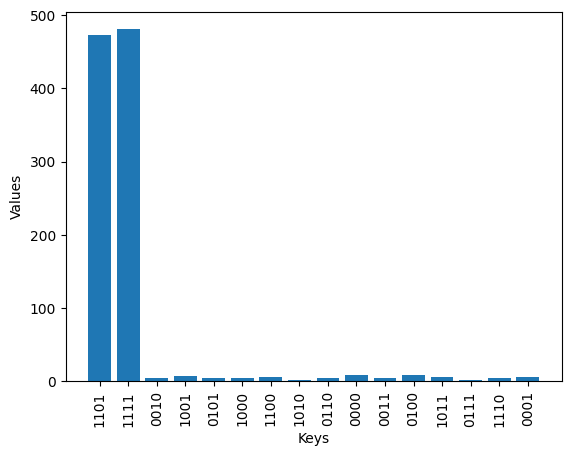

In [11]:
cir()
res = cir.measure(wires=[4, 5, 6, 7])
print(res)

# 准备x轴和y轴的数据
keys = list(res.keys())
values = list(res.values())

# 创建条形图
plt.bar(keys, values)

# 设置图表的标题和轴标签
plt.xlabel('Keys')
plt.ylabel('Values')

# 设置x轴的刻度标签，以便它们更容易阅读
plt.xticks(rotation=90)

# 显示图表
plt.show()

## 附录

[1] Portugal R. Quantum walks and search algorithms[M]. New York: Springer, 2013.

[2] Wanzambi E, Andersson S. Quantum computing: Implementing hitting time for coined quantum walks on regular graphs[J]. arXiv preprint arXiv:2108.02723, 2021.

[3] De Wolf R. Quantum computing: Lecture notes[J]. arXiv preprint arXiv:1907.09415, 2019.